# Notebook 1 — Python Data Processing & Exploratory Data Analysis
## NorthStar Urban Mobility and Logistics — Case Study
---
**What this notebook does:**
- Installs required libraries
- Loads all 9 CSV files
- Cleans and standardises the data (zone names, missing values, data types)
- Engineers new features useful for analysis
- Performs full EDA with charts and findings



## Section 1 — Install & Import Libraries

In [3]:
# Install any libraries not available
!pip install seaborn --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [4]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set a clean visual style for all charts
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("All libraries imported successfully.")

All libraries imported successfully.


## Section 2 — Upload & Load the Dataset


In [7]:
# Load raw CSV files directly from GitHub
raw_base_url = "https://raw.githubusercontent.com/m2007mahesh-byte/Northstar-case-study/main/northstar_dataset/"

hubs        = pd.read_csv(raw_base_url + "hubs.csv")
customers   = pd.read_csv(raw_base_url + "customers.csv")
drivers     = pd.read_csv(raw_base_url + "drivers.csv")
vehicles    = pd.read_csv(raw_base_url + "vehicles.csv")
orders      = pd.read_csv(raw_base_url + "orders.csv")
deliveries  = pd.read_csv(raw_base_url + "deliveries.csv")
incidents   = pd.read_csv(raw_base_url + "incidents.csv")
complaints  = pd.read_csv(raw_base_url + "complaints.csv")
app_events  = pd.read_csv(raw_base_url + "app_events.csv")

print("All 9 raw files loaded directly from GitHub.")
print()
print(f"{'File':<20} {'Rows':>6} {'Cols':>6}")
print("-" * 35)
for name, df in [("hubs", hubs), ("customers", customers), ("drivers", drivers),
                 ("vehicles", vehicles), ("orders", orders), ("deliveries", deliveries),
                 ("incidents", incidents), ("complaints", complaints), ("app_events", app_events)]:
    print(f"{name:<20} {df.shape[0]:>6} {df.shape[1]:>6}")

All 9 raw files loaded directly from GitHub.

File                   Rows   Cols
-----------------------------------
hubs                      8      5
customers               650      9
drivers                 170      8
vehicles                120      8
orders                 1250     11
deliveries              950     13
incidents               280      7
complaints              320     10
app_events              640     10


## Section 3 — Initial Data Inspection

In [8]:
# Quick look at each file — shape, columns, dtypes, and null counts
for name, df in [("hubs", hubs), ("customers", customers), ("drivers", drivers),
                 ("vehicles", vehicles), ("orders", orders), ("deliveries", deliveries),
                 ("incidents", incidents), ("complaints", complaints), ("app_events", app_events)]:

    print("=" * 55)
    print(f"  {name.upper()}  —  {df.shape[0]} rows x {df.shape[1]} cols")
    print("=" * 55)
    print(df.dtypes.to_string())

    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f"\nMissing values:")
        print(nulls.to_string())
    else:
        print("\nNo missing values.")
    print()

  HUBS  —  8 rows x 5 cols
hub_id              str
hub_name            str
zone                str
hub_type            str
capacity_score    int64

No missing values.

  CUSTOMERS  —  650 rows x 9 cols
customer_id                 str
age                       int64
home_zone                   str
customer_type               str
signup_date                 str
loyalty_score           float64
app_engagement_score    float64
preferred_channel           str
account_status              str

Missing values:
loyalty_score        20
preferred_channel    13

  DRIVERS  —  170 rows x 8 cols
driver_id               str
base_zone               str
employment_type         str
years_experience      int64
training_score      float64
driver_rating       float64
shift_preference        str
active_flag           int64

Missing values:
training_score    7

  VEHICLES  —  120 rows x 8 cols
vehicle_id                str
vehicle_type              str
assigned_zone             str
commission_date           s

In [6]:
# Print full hubs table — only 8 rows so useful to see everything
print("HUBS — complete reference table:")
print(hubs.to_string(index=False))

HUBS — complete reference table:
hub_id       hub_name      zone  hub_type  capacity_score
   H01 North Exchange     North  Dispatch              82
   H02     South Link     South  Dispatch              78
   H03      East Dock      East Warehouse              74
   H04      West Gate      West  Dispatch              69
   H05   Central Core   Central   Control              88
   H06    Airport Hub   Airport  Dispatch              71
   H07  Riverside Hub Riverside Warehouse              66
   H08  Midtown Relay   Central  Charging              63


## Section 4 — Data Cleaning

### Problem 1: Zone names are inconsistent across all files
The same 8 zones are spelled in 16 different ways:
`North`, `NORTH`, `north`, `Central`, `CENTRAL`, `Ctr`, `Riverside`, `RiverSide` etc.
This must be fixed first — otherwise grouping by zone gives wrong results.


In [7]:
# Mapping every variant to one clean standard name
zone_map = {
    "north":     "North",   "NORTH":     "North",
    "south":     "South",   "SOUTH":     "South",
    "east":      "East",    "EAST":      "East",
    "west":      "West",    "WEST":      "West",
    "central":   "Central", "CENTRAL":   "Central", "Ctr": "Central",
    "riverside": "Riverside","RIVERSIDE": "Riverside", "RiverSide": "Riverside",
    "airport":   "Airport", "AIRPORT":   "Airport",
    "North": "North", "South": "South", "East": "East",
    "West": "West", "Central": "Central", "Riverside": "Riverside", "Airport": "Airport"
}

In [8]:
# Apply to every column that holds zone values
orders["pickup_zone"]        = orders["pickup_zone"].map(zone_map).fillna(orders["pickup_zone"])
orders["dropoff_zone"]       = orders["dropoff_zone"].map(zone_map).fillna(orders["dropoff_zone"])
vehicles["assigned_zone"]    = vehicles["assigned_zone"].map(zone_map).fillna(vehicles["assigned_zone"])
drivers["base_zone"]         = drivers["base_zone"].map(zone_map).fillna(drivers["base_zone"])
customers["home_zone"]       = customers["home_zone"].map(zone_map).fillna(customers["home_zone"])
app_events["zone_context"]   = app_events["zone_context"].map(zone_map).fillna(app_events["zone_context"])

In [9]:
# Confirm — each zone column should now have exactly 7-8 unique values
print("Unique zones after cleaning:")
print("orders pickup_zone :", sorted(orders["pickup_zone"].unique()))
print("vehicles zone      :", sorted(vehicles["assigned_zone"].unique()))
print("drivers zone       :", sorted(drivers["base_zone"].unique()))

Unique zones after cleaning:
orders pickup_zone : ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
vehicles zone      : ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
drivers zone       : ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [10]:
# Fix date columns — convert string dates to proper datetime objects
date_cols = [
    (orders,     ["order_created_at"]),
    (deliveries, ["dispatch_time", "delivery_completed_at"]),
    (incidents,  ["reported_at"]),
    (complaints, ["created_at"]),
    (customers,  ["signup_date"]),
    (vehicles,   ["commission_date"]),
    (app_events, ["event_timestamp"])
]

for df, cols in date_cols:
    for col in cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print("Date columns converted to datetime.")

Date columns converted to datetime.


*  Handle missing values sensibly — fill or flag, not drop

In [11]:
# customers — fill missing loyalty_score with median, preferred_channel with 'Unknown'
customers["loyalty_score"]    = customers["loyalty_score"].fillna(customers["loyalty_score"].median())
customers["preferred_channel"]= customers["preferred_channel"].fillna("Unknown")

In [12]:
# drivers — fill missing training_score with median
drivers["training_score"] = drivers["training_score"].fillna(drivers["training_score"].median())

In [13]:
# vehicles — fill missing battery_health_pct with median
vehicles["battery_health_pct"] = vehicles["battery_health_pct"].fillna(vehicles["battery_health_pct"].median())

In [14]:
# orders — fill missing booking_channel with 'Unknown'
orders["booking_channel"] = orders["booking_channel"].fillna("Unknown")

In [15]:
# deliveries — fill missing customer_rating with median
deliveries["customer_rating_post_delivery"] = deliveries["customer_rating_post_delivery"].fillna(
    deliveries["customer_rating_post_delivery"].median()
)

In [16]:
# complaints — fill missing compensation_amount with 0 (not all complaints get compensation)
complaints["compensation_amount"] = complaints["compensation_amount"].fillna(0)

In [17]:
# incidents — fill missing resolved_hours with median
incidents["resolved_hours"] = incidents["resolved_hours"].fillna(incidents["resolved_hours"].median())

In [18]:
print("Missing values handled.")
print()

# Verify no unexpected nulls remain
for name, df in [("customers", customers), ("drivers", drivers), ("vehicles", vehicles),
                 ("orders", orders), ("deliveries", deliveries), ("complaints", complaints)]:
    remaining = df.isnull().sum().sum()
    print(f"{name:<15} remaining nulls: {remaining}")
print()
print("Note: 19 nulls in deliveries.delivery_completed_at are intentional.")
print("These 19 deliveries never completed — no timestamp should be fabricated.")

Missing values handled.

customers       remaining nulls: 0
drivers         remaining nulls: 0
vehicles        remaining nulls: 0
orders          remaining nulls: 0
deliveries      remaining nulls: 19
complaints      remaining nulls: 0

Note: 19 nulls in deliveries.delivery_completed_at are intentional.
These 19 deliveries never completed — no timestamp should be fabricated.


* Fix categorical columns — standardise with EXPLICIT maps only

In [19]:
# Delivery status — explicit map to preserve correct casing
status_map = {"OnTime": "OnTime", "Delayed": "Delayed", "Failed": "Failed",
              "Ontime": "OnTime", "ontime": "OnTime", "ONTIME": "OnTime",
              "delayed": "Delayed", "DELAYED": "Delayed",
              "failed": "Failed",  "FAILED": "Failed"}

deliveries["delivery_status"] = (
    deliveries["delivery_status"].str.strip()
    .map(status_map)
    .fillna(deliveries["delivery_status"])
)

In [20]:
# Incident severity — already correctly cased (Medium, Low, High, Critical)
incidents["severity"] = incidents["severity"].str.strip()

In [21]:
# Complaint severity and status — same, just strip
complaints["severity"] = complaints["severity"].str.strip()
complaints["status"]   = complaints["status"].str.strip()

print("Delivery status values (fixed):", deliveries["delivery_status"].unique())
print("Incident severity values       :", incidents["severity"].unique())
print("Complaint status values        :", complaints["status"].unique())
print()
print("OnTime count:", (deliveries['delivery_status']=='OnTime').sum())
print("Delayed count:", (deliveries['delivery_status']=='Delayed').sum())
print("Failed count:", (deliveries['delivery_status']=='Failed').sum())

Delivery status values (fixed): ['Failed' 'OnTime' 'Delayed']
Incident severity values       : ['Medium' 'Low' 'High' 'Critical']
Complaint status values        : ['Open' 'AwaitingCustomer' 'Resolved' 'Escalated']

OnTime count: 616
Delayed count: 202
Failed count: 132


## Section 5 — Feature Engineering
Creating new columns that will make the analysis much more powerful.

In [22]:
# Feature 1: delivery_delay_hours
# How many hours late was each delivery?
# We subtract dispatch_time from delivery_completed_at
deliveries["delivery_delay_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

In [23]:
# Negative values mean data errors (completed before dispatch) — cap at 0
deliveries["delivery_delay_hours"] = deliveries["delivery_delay_hours"].clip(lower=0)

print("delivery_delay_hours — sample stats:")
print(deliveries["delivery_delay_hours"].describe().round(2))

delivery_delay_hours — sample stats:
count    931.00
mean       9.61
std        8.57
min        0.00
25%        2.95
50%        7.07
75%       14.64
max       43.46
Name: delivery_delay_hours, dtype: float64


In [24]:
# Feature 2: is_high_override
# Flag deliveries where driver overrode the route 3 or more times
# High override count suggests either bad route planning or driver avoidance behaviour
deliveries["is_high_override"] = (deliveries["manual_route_override_count"] >= 3).astype(int)

high_override_count = deliveries["is_high_override"].sum()
print(f"Deliveries with 3+ route overrides: {high_override_count} out of {len(deliveries)}")
print(f"That is {high_override_count/len(deliveries)*100:.1f}% of all deliveries")

Deliveries with 3+ route overrides: 88 out of 950
That is 9.3% of all deliveries


In [25]:
# Feature 3: margin_proxy
# A rough profit estimate per delivery = order value minus fuel/charge cost
# Join orders + deliveries to compute this
order_delivery = orders.merge(deliveries[["order_id","delivery_status","fuel_or_charge_cost",
                                          "manual_route_override_count","delivery_delay_hours",
                                          "is_high_override","hub_id","driver_id","vehicle_id"]],
                               on="order_id", how="inner")

order_delivery["margin_proxy"] = order_delivery["order_value"] - order_delivery["fuel_or_charge_cost"]

print(f"Merged order+delivery table: {order_delivery.shape[0]} rows")
print()
print("Margin proxy by service type:")
print(order_delivery.groupby("service_type")["margin_proxy"].mean().round(2).sort_values())

Merged order+delivery table: 950 rows

Margin proxy by service type:
service_type
Medical      73.75
Retail       73.83
Parcel       77.07
Business     84.31
Passenger    84.79
Name: margin_proxy, dtype: float64


In [26]:
# Feature 4: repeat_complainer flag on customers
# Any customer who has complained 2 or more times is a repeat complainer
# These are high-risk customers who need attention
complaint_counts = complaints.groupby("customer_id").size().reset_index(name="complaint_count")
customers = customers.merge(complaint_counts, on="customer_id", how="left")
customers["complaint_count"]    = customers["complaint_count"].fillna(0).astype(int)
customers["repeat_complainer"]  = (customers["complaint_count"] >= 2).astype(int)

print(f"Total customers: {len(customers)}")
print(f"Repeat complainers (2+ complaints): {customers['repeat_complainer'].sum()}")

Total customers: 650
Repeat complainers (2+ complaints): 74


In [27]:
# Feature 5: vehicle age in years (from commission_date to today)
import datetime

today = pd.Timestamp.today()
vehicles["vehicle_age_years"] = ((today - vehicles["commission_date"]).dt.days / 365).round(1)

print("Vehicle age distribution:")
print(vehicles["vehicle_age_years"].describe().round(2))

Vehicle age distribution:
count    120.00
mean       1.21
std        0.59
min        0.20
25%        0.70
50%        1.20
75%        1.80
max        2.20
Name: vehicle_age_years, dtype: float64


## Section 6 — Exploratory Data Analysis & Visualisations

### 6.1 — Overall Delivery Performance

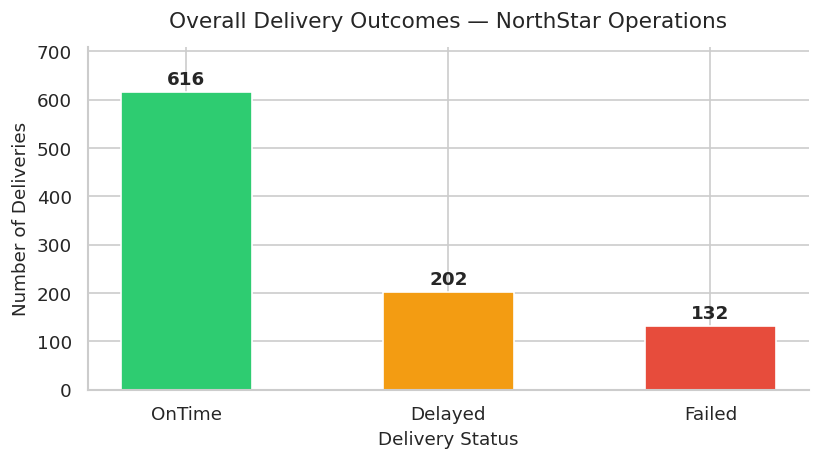


Key finding: Out of 950 deliveries:
  On Time : 616 (64.8%)
  Delayed : 202 (21.3%)
  Failed  : 132 (13.9%)


In [28]:
# Chart 1: Delivery status breakdown — how many on time, delayed, failed?
status_counts = deliveries["delivery_status"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(status_counts.index, status_counts.values,
              color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="white", width=0.5)

# Add value labels on top of each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Overall Delivery Outcomes — NorthStar Operations", fontsize=13, pad=12)
ax.set_xlabel("Delivery Status")
ax.set_ylabel("Number of Deliveries")
ax.set_ylim(0, max(status_counts.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig("chart1_delivery_status.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("Key finding: Out of 950 deliveries:")
print(f"  On Time : {status_counts.get('OnTime', 0)} ({status_counts.get('OnTime', 0)/950*100:.1f}%)")
print(f"  Delayed : {status_counts.get('Delayed',0)} ({status_counts.get('Delayed',0)/950*100:.1f}%)")
print(f"  Failed  : {status_counts.get('Failed',0)} ({status_counts.get('Failed',0)/950*100:.1f}%)")

### 6.2 — Hub Performance Analysis

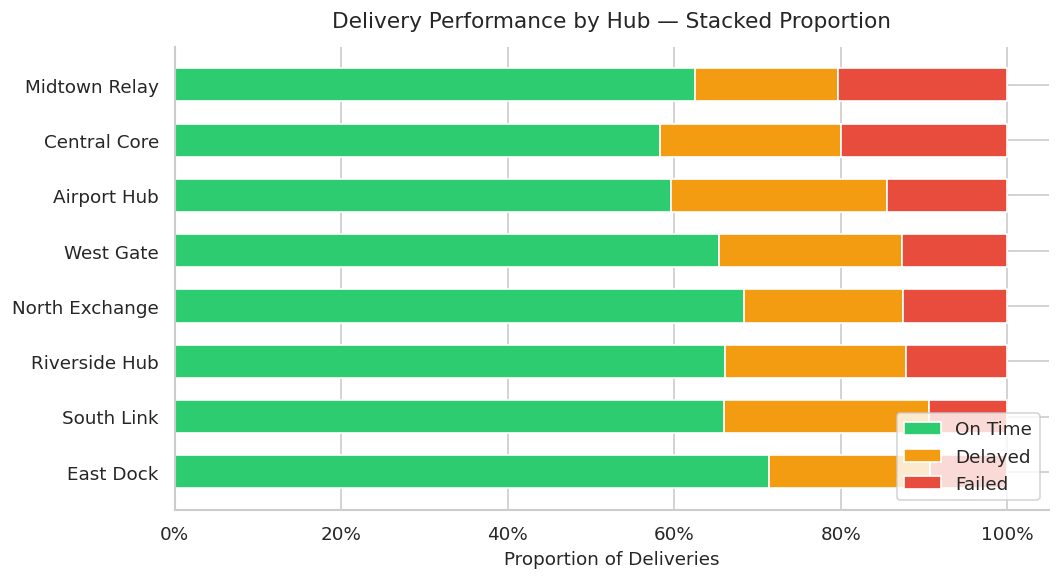


Hub failure rates (sorted worst to best):
  H08 — Midtown Relay        Failed: 20.3%
  H05 — Central Core         Failed: 20.0%
  H06 — Airport Hub          Failed: 14.4%
  H04 — West Gate            Failed: 12.6%
  H01 — North Exchange       Failed: 12.5%
  H07 — Riverside Hub        Failed: 12.2%
  H02 — South Link           Failed: 9.4%
  H03 — East Dock            Failed: 9.2%


In [29]:
# Chart 2: Delivery failure rate by hub — which hubs are worst?
hub_status = deliveries.groupby("hub_id")["delivery_status"].value_counts(normalize=True).unstack().fillna(0)
hub_status = hub_status.reset_index()

# Add hub names for readability
hub_names = hubs.set_index("hub_id")["hub_name"].to_dict()
hub_status["hub_name"] = hub_status["hub_id"].map(hub_names)
hub_status = hub_status.sort_values("Failed", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

y = range(len(hub_status))
width = 0.6

# Stacked horizontal bars
ax.barh(y, hub_status.get("OnTime", hub_status.get("Ontime", 0)), width,
        label="On Time", color="#2ecc71")
ax.barh(y, hub_status.get("Delayed", 0), width,
        left=hub_status.get("OnTime", hub_status.get("Ontime", 0)),
        label="Delayed", color="#f39c12")
ax.barh(y, hub_status.get("Failed", 0), width,
        left=hub_status.get("OnTime", hub_status.get("Ontime", 0)) + hub_status.get("Delayed", 0),
        label="Failed", color="#e74c3c")

ax.set_yticks(list(y))
ax.set_yticklabels(hub_status["hub_name"].tolist())
ax.set_xlabel("Proportion of Deliveries")
ax.set_title("Delivery Performance by Hub — Stacked Proportion", pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.savefig("chart2_hub_performance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nHub failure rates (sorted worst to best):")
hub_fail = deliveries.groupby("hub_id")["delivery_status"].apply(
    lambda x: (x == "Failed").mean() * 100
).round(1).sort_values(ascending=False)
for hub_id, rate in hub_fail.items():
    print(f"  {hub_id} — {hub_names.get(hub_id,'?'):<20} Failed: {rate}%")

### 6.3 — Service Type Analysis

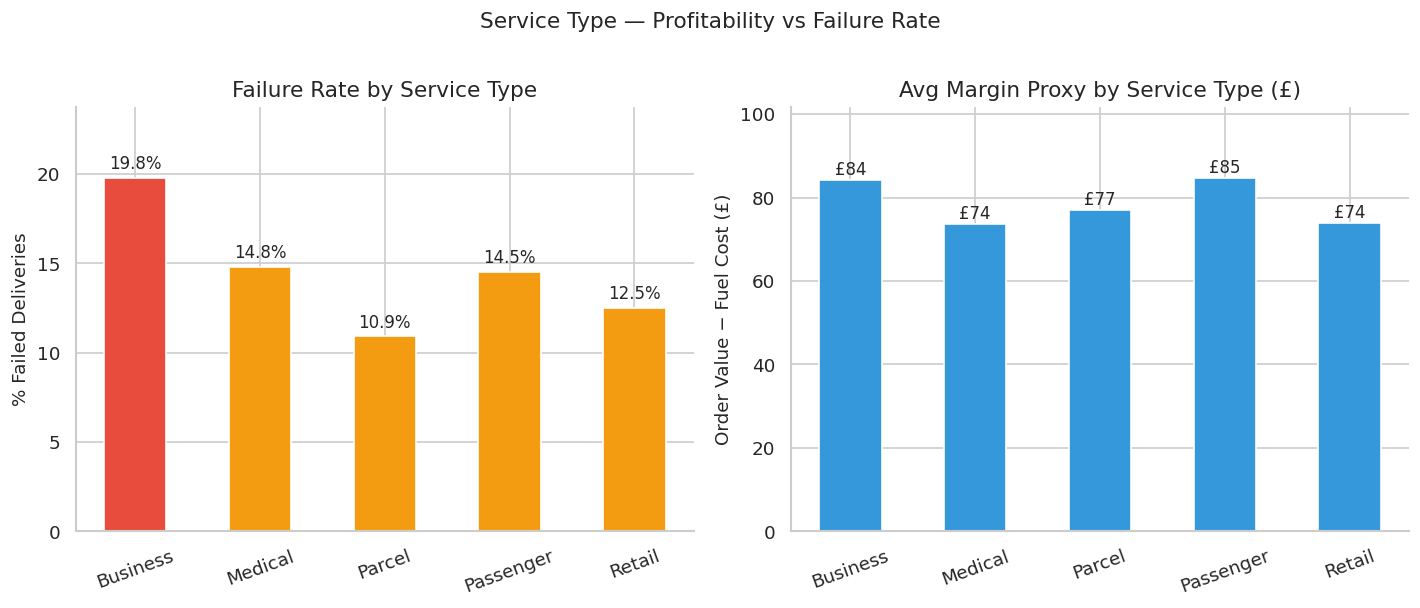


Key finding: Medical and Retail have the lowest margins AND high failure rates.
Service		Fail%		Avg Margin
Business        19.8%		£84.31
Medical         14.8%		£73.75
Parcel          10.9%		£77.07
Passenger       14.5%		£84.79
Retail          12.5%		£73.83


In [30]:
# Chart 3: Failure rate AND margin proxy by service type side by side
service_fail = order_delivery.groupby("service_type")["delivery_status"].apply(
    lambda x: (x == "Failed").mean() * 100
).round(1)

service_margin = order_delivery.groupby("service_type")["margin_proxy"].mean().round(2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: failure rate
colors = ["#e74c3c" if v > 15 else "#f39c12" if v > 10 else "#2ecc71"
          for v in service_fail.values]
bars1 = ax1.bar(service_fail.index, service_fail.values, color=colors, edgecolor="white", width=0.5)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)
ax1.set_title("Failure Rate by Service Type")
ax1.set_ylabel("% Failed Deliveries")
ax1.set_ylim(0, max(service_fail.values) * 1.2)
ax1.tick_params(axis="x", rotation=20)
sns.despine(ax=ax1)

# Right: margin proxy
bars2 = ax2.bar(service_margin.index, service_margin.values,
                color=["#3498db"]*len(service_margin), edgecolor="white", width=0.5)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"£{bar.get_height():.0f}", ha="center", va="bottom", fontsize=10)
ax2.set_title("Avg Margin Proxy by Service Type (£)")
ax2.set_ylabel("Order Value − Fuel Cost (£)")
ax2.set_ylim(0, max(service_margin.values) * 1.2)
ax2.tick_params(axis="x", rotation=20)
sns.despine(ax=ax2)

plt.suptitle("Service Type — Profitability vs Failure Rate", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("chart3_service_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey finding: Medical and Retail have the lowest margins AND high failure rates.")
print("Service\t\tFail%\t\tAvg Margin")
for svc in service_fail.index:
    print(f"{svc:<15} {service_fail[svc]}%\t\t£{service_margin[svc]}")

### 6.4 — Zone-Level Failure Analysis

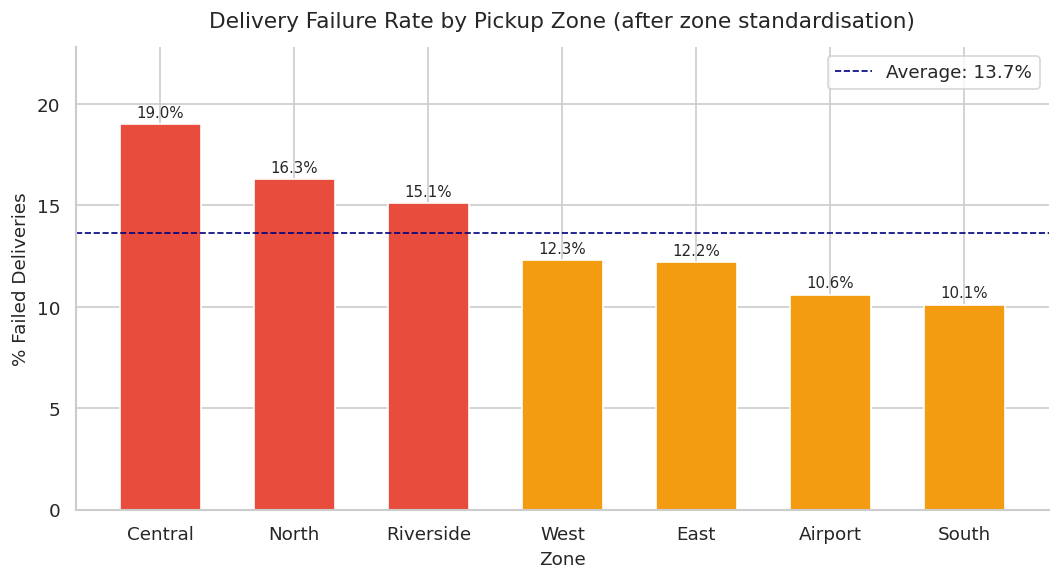


Zone failure rates (high to low):
  Central      19.0% ← HIGH RISK
  North        16.3% ← HIGH RISK
  Riverside    15.1% ← HIGH RISK
  West         12.3%
  East         12.2%
  Airport      10.6%
  South        10.1%


In [31]:
# Chart 4: Failure rate by pickup zone — which zones perform worst?
zone_fail = order_delivery.groupby("pickup_zone")["delivery_status"].apply(
    lambda x: (x == "Failed").mean() * 100
).round(1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#e74c3c" if v > 15 else "#f39c12" if v > 10 else "#2ecc71"
              for v in zone_fail.values]
bars = ax.bar(zone_fail.index, zone_fail.values, color=bar_colors, edgecolor="white", width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_title("Delivery Failure Rate by Pickup Zone (after zone standardisation)", pad=12)
ax.set_ylabel("% Failed Deliveries")
ax.set_xlabel("Zone")
ax.set_ylim(0, max(zone_fail.values) * 1.2)
ax.axhline(y=zone_fail.mean(), color="navy", linestyle="--", linewidth=1,
           label=f"Average: {zone_fail.mean():.1f}%")
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("chart4_zone_failures.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nZone failure rates (high to low):")
for zone, rate in zone_fail.items():
    flag = " ← HIGH RISK" if rate > 15 else ""
    print(f"  {zone:<12} {rate}%{flag}")

### 6.5 — Vehicle Fleet Health

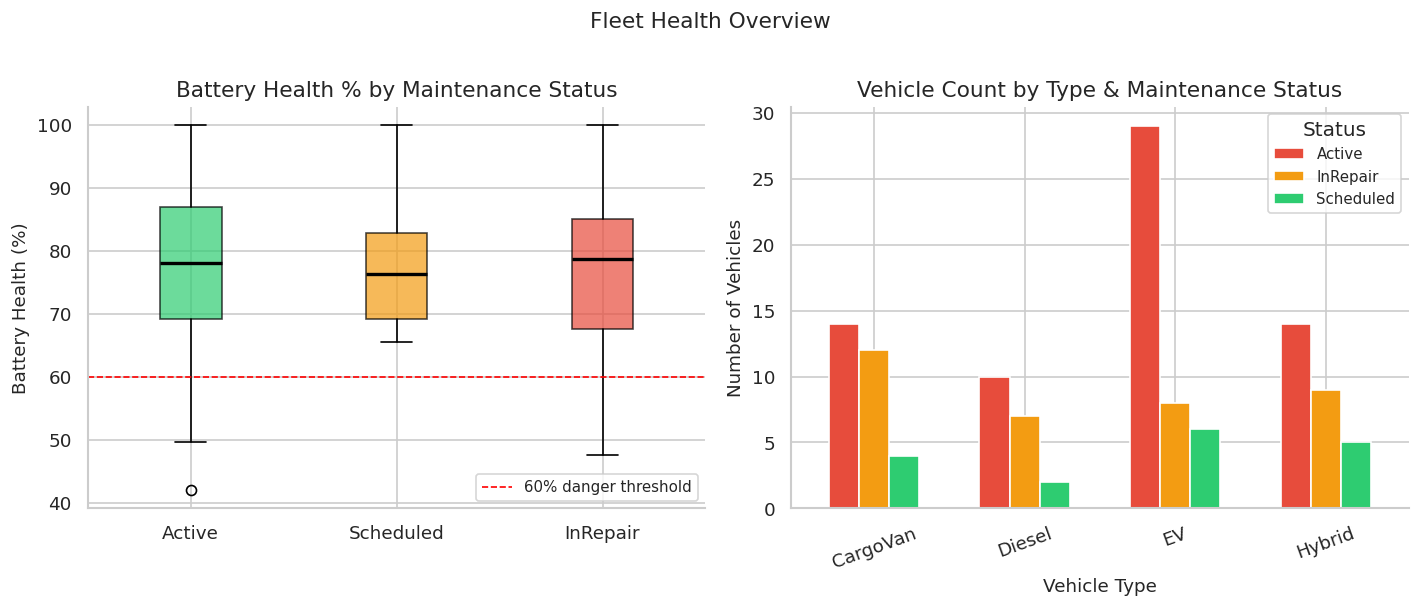


Critical vehicles (InRepair + battery < 65%): 7
vehicle_id vehicle_type  battery_health_pct maintenance_status
      V010     CargoVan                50.7           InRepair
      V037     CargoVan                56.6           InRepair
      V070     CargoVan                62.6           InRepair
      V084     CargoVan                47.6           InRepair
      V108       Diesel                54.6           InRepair
      V109       Hybrid                60.6           InRepair
      V113       Hybrid                58.9           InRepair


In [32]:
# Chart 5: Battery health distribution by vehicle type and maintenance status
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: battery health by maintenance status — box plot
maintenance_order = ["Active", "Scheduled", "InRepair"]
data_for_box = [vehicles[vehicles["maintenance_status"] == s]["battery_health_pct"].dropna()
                for s in maintenance_order]

bp = ax1.boxplot(data_for_box, labels=maintenance_order, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2))
colors_box = ["#2ecc71", "#f39c12", "#e74c3c"]
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_title("Battery Health % by Maintenance Status")
ax1.set_ylabel("Battery Health (%)")
ax1.axhline(y=60, color="red", linestyle="--", linewidth=1, label="60% danger threshold")
ax1.legend(fontsize=9)
sns.despine(ax=ax1)

# Right: vehicle count by type and maintenance status
veh_count = vehicles.groupby(["vehicle_type", "maintenance_status"]).size().unstack(fill_value=0)
veh_count.plot(kind="bar", ax=ax2, color=["#e74c3c","#f39c12","#2ecc71"],
               edgecolor="white", width=0.6)
ax2.set_title("Vehicle Count by Type & Maintenance Status")
ax2.set_ylabel("Number of Vehicles")
ax2.set_xlabel("Vehicle Type")
ax2.tick_params(axis="x", rotation=20)
ax2.legend(title="Status", fontsize=9)
sns.despine(ax=ax2)

plt.suptitle("Fleet Health Overview", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("chart5_fleet_health.png", dpi=150, bbox_inches="tight")
plt.show()

# Highlight critical vehicles
critical_vehicles = vehicles[
    (vehicles["maintenance_status"] == "InRepair") &
    (vehicles["battery_health_pct"] < 65)
]
print(f"\nCritical vehicles (InRepair + battery < 65%): {len(critical_vehicles)}")
print(critical_vehicles[["vehicle_id","vehicle_type","battery_health_pct","maintenance_status"]].to_string(index=False))

### 6.6 — Manual Route Override Analysis

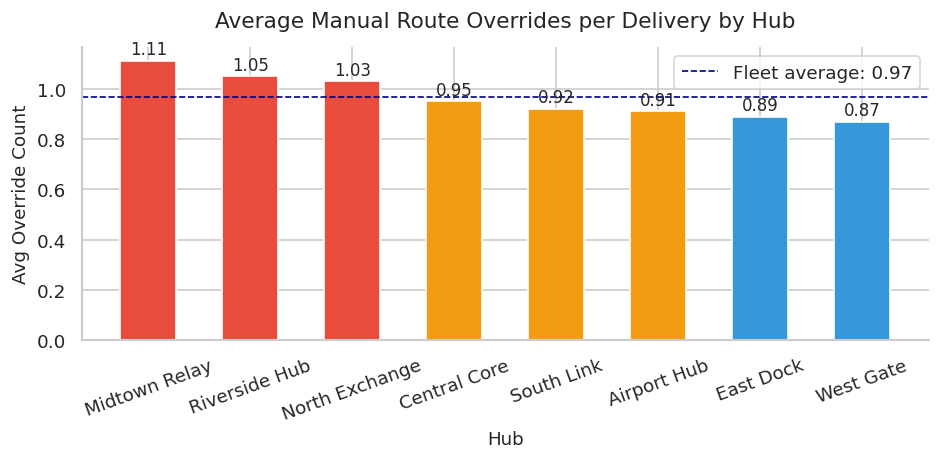

In [33]:
# Chart 6: Manual route overrides by hub — are some hubs pushing drivers to override?
override_by_hub = deliveries.groupby("hub_id")["manual_route_override_count"].mean().round(2)
override_by_hub.index = override_by_hub.index.map(hub_names)
override_by_hub = override_by_hub.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ["#e74c3c" if v > 1.0 else "#f39c12" if v > 0.9 else "#3498db"
              for v in override_by_hub.values]
bars = ax.bar(override_by_hub.index, override_by_hub.values,
              color=bar_colors, edgecolor="white", width=0.55)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Average Manual Route Overrides per Delivery by Hub", pad=12)
ax.set_ylabel("Avg Override Count")
ax.set_xlabel("Hub")
ax.axhline(y=override_by_hub.mean(), color="navy", linestyle="--", linewidth=1,
           label=f"Fleet average: {override_by_hub.mean():.2f}")
ax.legend()
ax.tick_params(axis="x", rotation=20)
sns.despine()
plt.tight_layout()
plt.savefig("chart6_overrides_by_hub.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.7 — Complaint Analysis

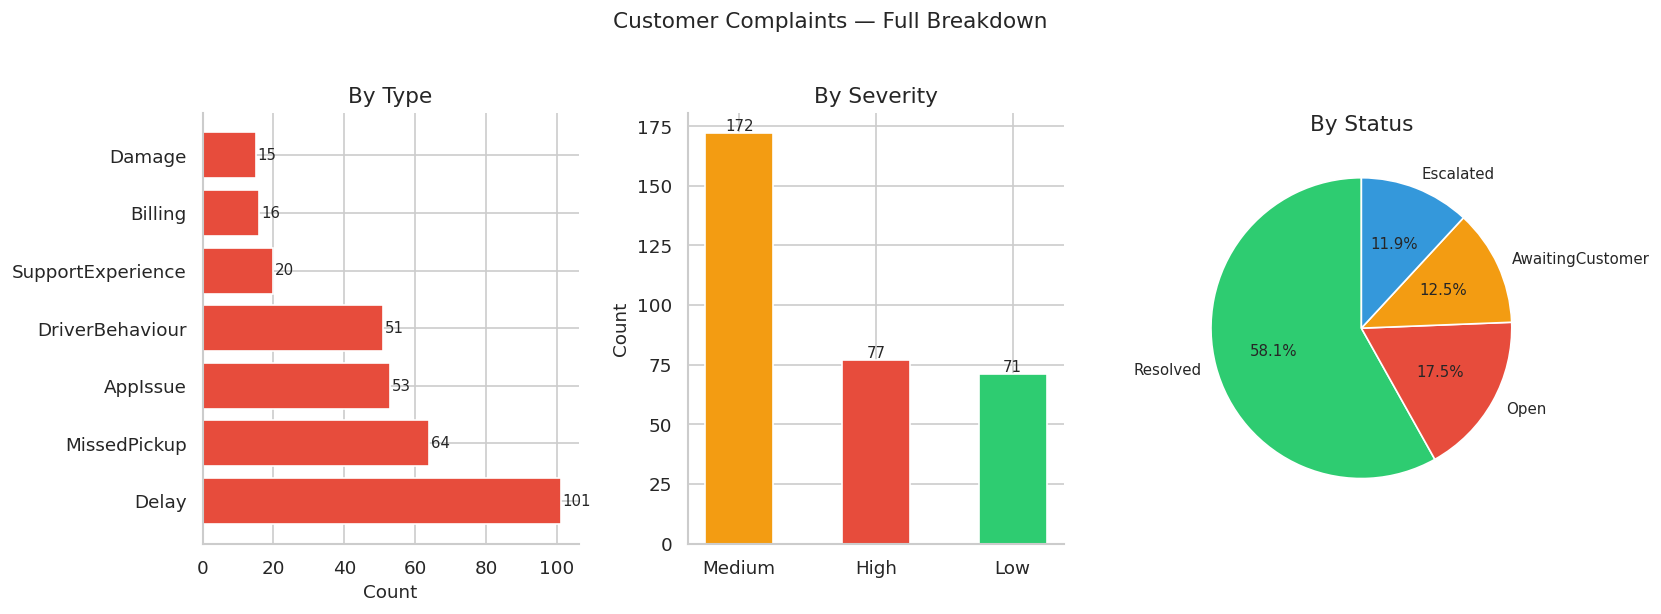


Total complaints: 320
Still Open: 56
Escalated: 38
Avg resolution days: 7.9


In [34]:
# Chart 7: Complaints breakdown — type, severity, status

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Type
comp_type = complaints["complaint_type"].value_counts()
axes[0].barh(comp_type.index, comp_type.values, color="#e74c3c", edgecolor="white")
axes[0].set_title("By Type")
axes[0].set_xlabel("Count")
for i, v in enumerate(comp_type.values):
    axes[0].text(v + 0.5, i, str(v), va="center", fontsize=9)
sns.despine(ax=axes[0])

# Severity
comp_sev = complaints["severity"].value_counts()
colors_sev = {"High": "#e74c3c", "Medium": "#f39c12", "Low": "#2ecc71"}
bar_colors_sev = [colors_sev.get(s, "#3498db") for s in comp_sev.index]
axes[1].bar(comp_sev.index, comp_sev.values, color=bar_colors_sev, edgecolor="white", width=0.5)
axes[1].set_title("By Severity")
axes[1].set_ylabel("Count")
for i, v in enumerate(comp_sev.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=9)
sns.despine(ax=axes[1])

# Status
comp_status = complaints["status"].value_counts()
axes[2].pie(comp_status.values, labels=comp_status.index, autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c", "#f39c12", "#3498db"],
            startangle=90, textprops={"fontsize": 9})
axes[2].set_title("By Status")

plt.suptitle("Customer Complaints — Full Breakdown", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("chart7_complaints.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTotal complaints: {len(complaints)}")
print(f"Still Open: {(complaints['status'] == 'Open').sum()}")
print(f"Escalated: {(complaints['status'] == 'Escalated').sum()}")
print(f"Avg resolution days: {complaints['resolution_days'].mean():.1f}")

### 6.8 — The OnTime vs Complaint Mismatch (Key Business Finding)

Deliveries marked 'OnTime' that still generated complaints: 149

Complaint types from supposedly on-time deliveries:
complaint_type
Delay                44
DriverBehaviour      29
MissedPickup         25
AppIssue             25
SupportExperience    11
Damage                8
Billing               7


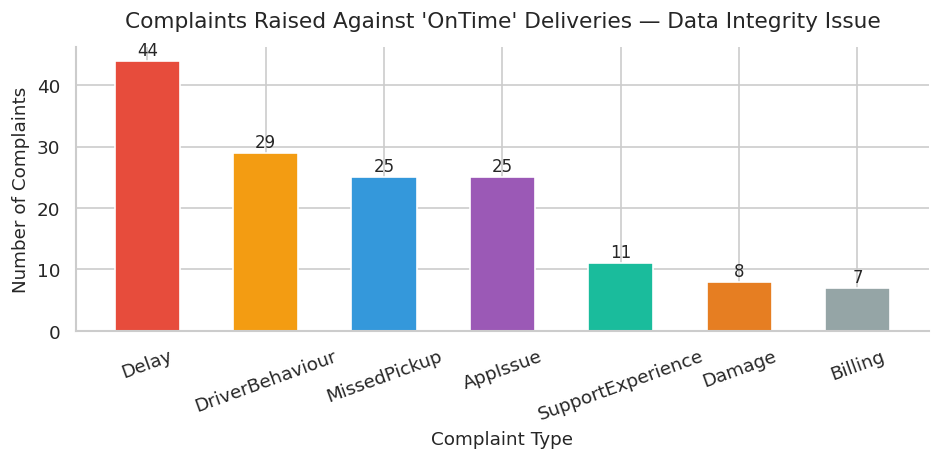


Key insight: 149 'OnTime' deliveries have complaints.
The system is marking deliveries as complete when customers still experienced problems.
This is the exact data fragmentation problem the CX Director described.


In [35]:
# CRITICAL FINDING: Deliveries marked OnTime that still generated complaints
# This proves the data integrity problem described in the case study
ontime_with_complaint = deliveries[deliveries["delivery_status"] == "OnTime"].merge(
    complaints[["order_id", "complaint_type", "severity"]],
    on="order_id",
    how="inner"
)

print(f"Deliveries marked 'OnTime' that still generated complaints: {len(ontime_with_complaint)}")
print()
print("Complaint types from supposedly on-time deliveries:")
print(ontime_with_complaint["complaint_type"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ct = ontime_with_complaint["complaint_type"].value_counts()
bars = ax.bar(ct.index, ct.values,
              color=["#e74c3c","#f39c12","#3498db","#9b59b6","#1abc9c","#e67e22","#95a5a6"],
              edgecolor="white", width=0.55)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)

ax.set_title("Complaints Raised Against 'OnTime' Deliveries — Data Integrity Issue", pad=12)
ax.set_ylabel("Number of Complaints")
ax.set_xlabel("Complaint Type")
ax.tick_params(axis="x", rotation=20)
sns.despine()
plt.tight_layout()
plt.savefig("chart8_ontime_complaints.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("Key insight: 149 'OnTime' deliveries have complaints.")
print("The system is marking deliveries as complete when customers still experienced problems.")
print("This is the exact data fragmentation problem the CX Director described.")

### 6.9 — App Platform Analysis

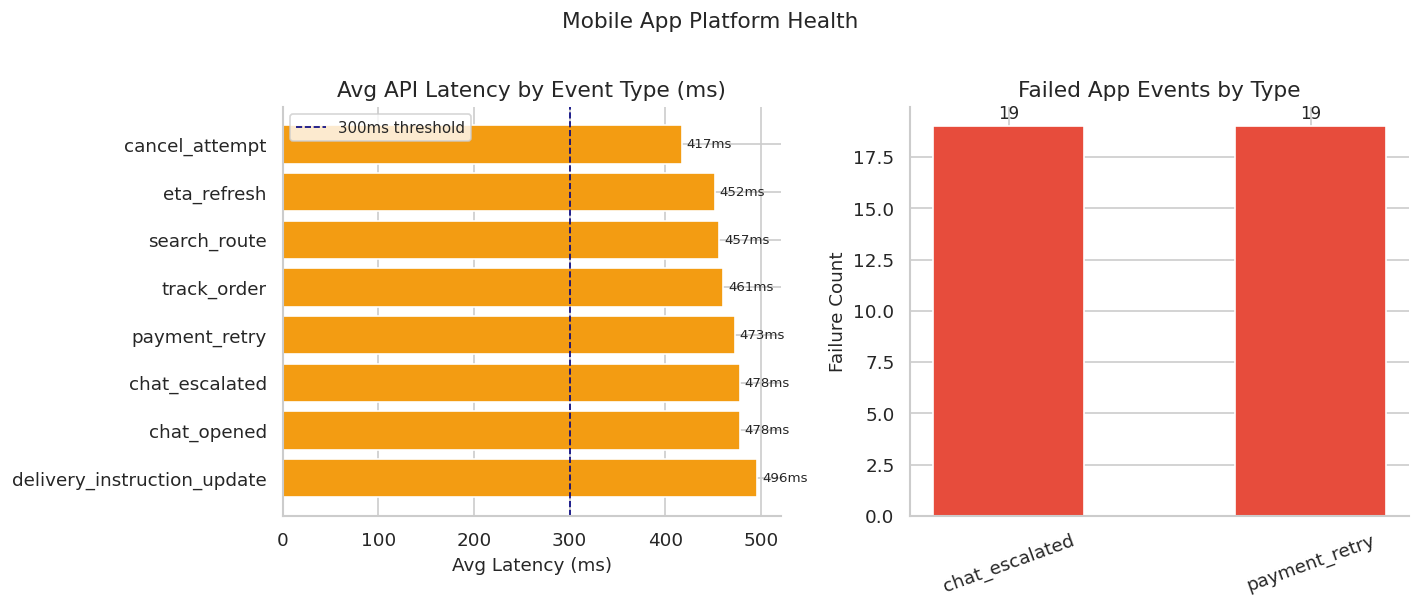


Failed event rates:
event_type
cancel_attempt                   0 / 28 = 0.0%
chat_escalated                 19 / 38 = 50.0%
chat_opened                      0 / 88 = 0.0%
delivery_instruction_update      0 / 75 = 0.0%
eta_refresh                     0 / 105 = 0.0%
payment_retry                  19 / 69 = 27.5%
search_route                     0 / 99 = 0.0%
track_order                     0 / 138 = 0.0%


In [36]:
# Chart 9: App events — latency and failure patterns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: API latency distribution by event type
latency_by_event = app_events.groupby("event_type")["api_latency_ms"].mean().sort_values(ascending=False)
bars = ax1.barh(latency_by_event.index, latency_by_event.values,
                color=["#e74c3c" if v > 500 else "#f39c12" if v > 300 else "#2ecc71"
                       for v in latency_by_event.values],
                edgecolor="white")
ax1.axvline(x=300, color="navy", linestyle="--", linewidth=1, label="300ms threshold")
ax1.set_title("Avg API Latency by Event Type (ms)")
ax1.set_xlabel("Avg Latency (ms)")
ax1.legend(fontsize=9)
for bar in bars:
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f"{bar.get_width():.0f}ms", va="center", fontsize=8)
sns.despine(ax=ax1)

# Right: success vs failure by event type
app_fail = app_events.groupby("event_type")["success_flag"].apply(
    lambda x: (x == 0).sum()
).sort_values(ascending=False)
app_fail = app_fail[app_fail > 0]
ax2.bar(app_fail.index, app_fail.values, color="#e74c3c", edgecolor="white", width=0.5)
ax2.set_title("Failed App Events by Type")
ax2.set_ylabel("Failure Count")
ax2.tick_params(axis="x", rotation=20)
for i, v in enumerate(app_fail.values):
    ax2.text(i, v + 0.2, str(v), ha="center", va="bottom", fontsize=10)
sns.despine(ax=ax2)

plt.suptitle("Mobile App Platform Health", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("chart9_app_events.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFailed event rates:")
fail_rate = app_events.groupby("event_type")["success_flag"].apply(
    lambda x: f"{(x==0).sum()} / {len(x)} = {(x==0).mean()*100:.1f}%"
)
print(fail_rate.to_string())

### 6.10 — Incident Pattern Analysis

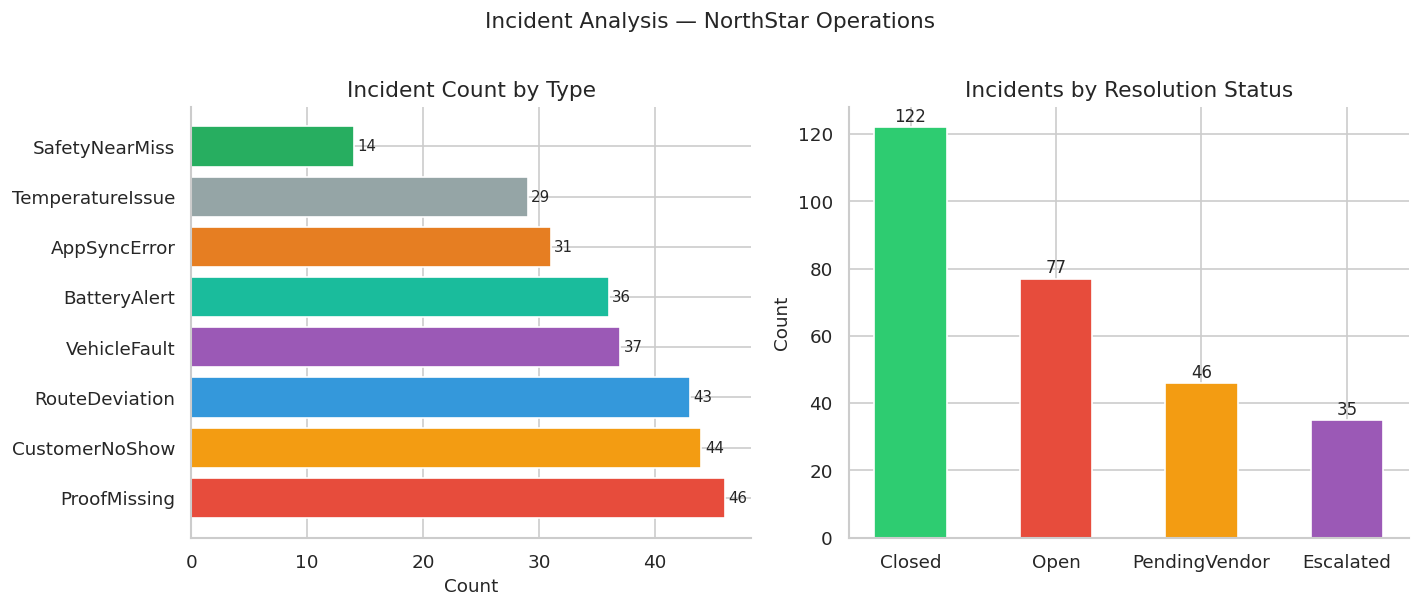


Critical incidents still Open or Escalated: 11


In [37]:
# Chart 10: Incident types and their resolution status
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: incident type counts
inc_type = incidents["incident_type"].value_counts()
ax1.barh(inc_type.index, inc_type.values,
         color=["#e74c3c","#f39c12","#3498db","#9b59b6","#1abc9c","#e67e22","#95a5a6","#27ae60"],
         edgecolor="white")
ax1.set_title("Incident Count by Type")
ax1.set_xlabel("Count")
for i, v in enumerate(inc_type.values):
    ax1.text(v + 0.3, i, str(v), va="center", fontsize=9)
sns.despine(ax=ax1)

# Right: resolution status breakdown
inc_res = incidents["resolution_status"].value_counts()
colors_res = {"Closed": "#2ecc71", "Open": "#e74c3c",
              "PendingVendor": "#f39c12", "Escalated": "#9b59b6"}
bar_colors_res = [colors_res.get(s, "#3498db") for s in inc_res.index]
ax2.bar(inc_res.index, inc_res.values, color=bar_colors_res, edgecolor="white", width=0.5)
ax2.set_title("Incidents by Resolution Status")
ax2.set_ylabel("Count")
for i, v in enumerate(inc_res.values):
    ax2.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=10)
sns.despine(ax=ax2)

plt.suptitle("Incident Analysis — NorthStar Operations", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("chart10_incidents.png", dpi=150, bbox_inches="tight")
plt.show()

open_critical = incidents[(incidents["resolution_status"].isin(["Open","Escalated"])) &
                           (incidents["severity"] == "Critical")]
print(f"\nCritical incidents still Open or Escalated: {len(open_critical)}")

## Section 7 — Summary Statistics Table

In [38]:
# Print a clean summary of all key findings for the report
print("=" * 60)
print("   NORTHSTAR — PYTHON EDA SUMMARY OF KEY FINDINGS")
print("=" * 60)

total_orders    = len(orders)
total_deliveries= len(deliveries)
failed          = (deliveries["delivery_status"] == "Failed").sum()
delayed         = (deliveries["delivery_status"] == "Delayed").sum()
ontime          = (deliveries['delivery_status'] == 'OnTime').sum()

print(f"\nTotal Orders         : {total_orders}")
print(f"Total Deliveries     : {total_deliveries}")
print(f"Orders with No Delivery Record: {total_orders - total_deliveries} ({(total_orders-total_deliveries)/total_orders*100:.1f}%)")
print(f"\nOn Time              : {ontime} ({ontime/total_deliveries*100:.1f}%)")
print(f"Delayed              : {delayed} ({delayed/total_deliveries*100:.1f}%)")
print(f"Failed               : {failed} ({failed/total_deliveries*100:.1f}%)")
print(f"\nOnTime with Complaints: {len(ontime_with_complaint)} (data integrity failure)")
print(f"\nTotal Complaints     : {len(complaints)}")
print(f"Open/Escalated       : {(complaints['status'].isin(['Open','Escalated'])).sum()}")
print(f"Avg Resolution Days  : {complaints['resolution_days'].mean():.1f}")
print(f"\nTotal Incidents      : {len(incidents)}")
print(f"Unresolved Incidents : {(incidents['resolution_status'].isin(['Open','PendingVendor','Escalated'])).sum()}")
print(f"\nVehicles InRepair    : {(vehicles['maintenance_status']=='InRepair').sum()} / {len(vehicles)}")
print(f"Low Battery (<65%)   : {(vehicles['battery_health_pct'] < 65).sum()}")
print(f"\nApp Event Failures   : {(app_events['success_flag']==0).sum()} / {len(app_events)}")
print(f"High Latency (>1s)   : {(app_events['api_latency_ms']>1000).sum()}")
print()
print("Worst Hubs (failure rate):")
hub_fail_summary = deliveries.groupby("hub_id")["delivery_status"].apply(
    lambda x: (x=="Failed").mean()*100).round(1).sort_values(ascending=False)
for hid, rate in hub_fail_summary.items():
    print(f"  {hid} — {hub_names.get(hid,'?'):<20} {rate}%")
print()
print("Saved charts: chart1 through chart10 as PNG files.")

   NORTHSTAR — PYTHON EDA SUMMARY OF KEY FINDINGS

Total Orders         : 1250
Total Deliveries     : 950
Orders with No Delivery Record: 300 (24.0%)

On Time              : 616 (64.8%)
Delayed              : 202 (21.3%)
Failed               : 132 (13.9%)

OnTime with Complaints: 149 (data integrity failure)

Total Complaints     : 320
Open/Escalated       : 94
Avg Resolution Days  : 7.9

Total Incidents      : 280
Unresolved Incidents : 158

Vehicles InRepair    : 36 / 120
Low Battery (<65%)   : 20

App Event Failures   : 38 / 640
High Latency (>1s)   : 25

Worst Hubs (failure rate):
  H08 — Midtown Relay        20.3%
  H05 — Central Core         20.0%
  H06 — Airport Hub          14.4%
  H04 — West Gate            12.6%
  H01 — North Exchange       12.5%
  H07 — Riverside Hub        12.2%
  H02 — South Link           9.4%
  H03 — East Dock            9.2%

Saved charts: chart1 through chart10 as PNG files.


In [39]:
# Save the cleaned dataframes for use in Notebook 2 (SQL + R)
orders.to_csv("orders_clean.csv", index=False)
deliveries.to_csv("deliveries_clean.csv", index=False)
customers.to_csv("customers_clean.csv", index=False)
drivers.to_csv("drivers_clean.csv", index=False)
vehicles.to_csv("vehicles_clean.csv", index=False)
incidents.to_csv("incidents_clean.csv", index=False)
complaints.to_csv("complaints_clean.csv", index=False)
app_events.to_csv("app_events_clean.csv", index=False)
hubs.to_csv("hubs_clean.csv", index=False)

print("All cleaned files saved as *_clean.csv")
print("Use these in Notebook 2 and Notebook 3.")

All cleaned files saved as *_clean.csv
Use these in Notebook 2 and Notebook 3.
